In [1]:
import jax
import jax.numpy as jnp
import diffrax as dfx
import equinox as eqx

import matplotlib.pyplot as plt

from models import HamiltonianNN, NeuralODE
from vector_fields import vector_field_triangular_nonlinear_mass_spring_2d, vector_field_hnn_potenergy, vector_field_hnn_totenergy, vector_field_node
from utilities import Params, integrate_vector_field, split_train_val, save_model, load_model
from train import train_partially_observed, train_fully_observed

ImportError: cannot import name 'vector_field_node' from 'vector_fields' (/Users/sunnivameltzer/Documents/SINTEF/Projects/partially-observed-systems/systems/triangular_nonlinear_triple_mass_spring_2d/vector_fields.py)

In [ ]:
key = jax.random.PRNGKey(0)

In [ ]:
def zero_total_momentum_p(p):
    """
    Enforce total (linear) momentum = 0.

    p: array (..., n_bodies, dim) momenta
    returns p' with sum_i p'_i = 0
    """
    P_tot = jnp.sum(p, axis=-2, keepdims=True)  # (..., 1, dim)
    return p - P_tot / p.shape[-2]

In [ ]:
def sample_ic_batch(key: jax.random.PRNGKey, N: int):
    """
    Samples initial conditions for the 2D triangular 3-mass system.

    Returns shape (N, 12):
      [x0, y0, x1, y1, x2, y2, px0, py0, px1, py1, px2, py2]
    """
    key0, key1, key2, key3 = jax.random.split(key, 4)

    # --- Positions ---
    x0 = jax.random.uniform(key0, (N,), minval=0.3, maxval=0.7)
    y0 = jax.random.uniform(key0, (N,), minval=1.0, maxval=1.4)

    x1 = jax.random.uniform(key1, (N,), minval=0.1, maxval=0.4)
    y1 = jax.random.uniform(key1, (N,), minval=0.1, maxval=0.5)

    x2 = jax.random.uniform(key2, (N,), minval=0.6, maxval=0.9)
    y2 = jax.random.uniform(key2, (N,), minval=0.1, maxval=0.5)

    r = jnp.stack([x0, y0, x1, y1, x2, y2], axis=-1)  # (N, 6)

    # --- Momenta ---
    p = jax.random.uniform(key3, (N, 3, 2), minval=-0.7, maxval=0.7)  # (N,3,2)
    p = zero_total_momentum_p(p)  # enforce sum_i p_i = 0
    p = p.reshape(N, 6)

    return jnp.concatenate([r, p], axis=-1)

In [ ]:
system_params = Params(m0=1.0, m1=1.0, m2=1.0, k01=0.1, k12=0.1, k02=0.1, L01=0.9, L12=0.9, L02=0.9)
ts = jnp.linspace(0.0, 10.0, 1001)

y0s = sample_ic_batch(key, N=2000)

solve_batch = integrate_vector_field(ts=ts, term=vector_field_triangular_nonlinear_mass_spring_2d)
ys_all = solve_batch(model=None, params=system_params, y0s=y0s)   # (N, T, 6)
print("ys_all:", ys_all.shape)


# plt.figure()
# for i in range(ys_all.shape[0]):
#     plt.plot(ts, ys_all[i, :, 0], alpha=0.3, color='black', lw=0.3)  # x0
# plt.title('Position of mass 0 over time for 2000 samples')
# plt.xlabel('Time')
# plt.ylabel('Position x0')
# plt.show()

ys_all: (2000, 1001, 12)


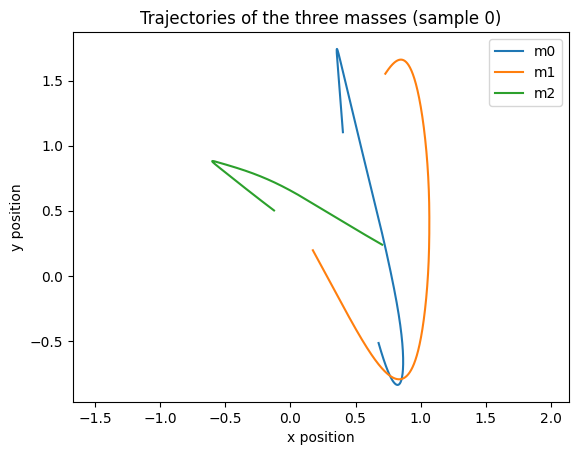

In [ ]:
plt.plot(ys_all[0, :, 0], ys_all[0, :, 1], label='m0')
plt.plot(ys_all[0, :, 2], ys_all[0, :, 3], label='m1')
plt.plot(ys_all[0, :, 4], ys_all[0, :, 5], label='m2')
plt.title('Trajectories of the three masses (sample 0)')
plt.xlabel('x position')
plt.ylabel('y position')
plt.legend()
plt.axis('equal')
plt.show()

### Initialize neural networks

In [7]:
key, subkey = jax.random.split(key)
hnn_potenergy = HamiltonianNN(key=subkey, input_dim=6, hidden_dim=64)
hnn_potenergy_params, hnn_potenergy_static = eqx.partition(hnn_potenergy, eqx.is_array)

key, subkey = jax.random.split(key)
hnn_totenergy = HamiltonianNN(key=subkey, input_dim=12, hidden_dim=64)
hnn_totenergy_params, hnn_totenergy_static = eqx.partition(hnn_totenergy, eqx.is_array)

key, subkey = jax.random.split(key)
node = NeuralODE(key=subkey, input_dim=12, hidden_dim=64, output_dim=6, relative_distances=False)
node_params, node_static = eqx.partition(node, eqx.is_array)

In [8]:
import jax
import jax.numpy as jnp
 
def count_parameters(param_tree):
    """Return total number of trainable parameters in a JAX/Flax param pytree."""
    leaves = jax.tree_util.tree_leaves(param_tree)
    return sum(int(jnp.prod(jnp.array(leaf.shape))) for leaf in leaves)
 
nparams = count_parameters(hnn_totenergy_params)
print(f"Total number of trainable parameters: {nparams}")
 

Total number of trainable parameters: 9025


In [9]:
key, subkey = jax.random.split(key)
train_all, val_all = split_train_val(subkey, ys_all, 0.85)

### Train HNN model 1 (learning potential energy)

In [10]:
system_params

Params(
  m0=1.0,
  m1=1.0,
  m2=1.0,
  k01=0.1,
  k12=0.1,
  k02=0.1,
  L01=0.9,
  L12=0.9,
  L02=0.9
)

In [11]:
train_all.shape

(1700, 1001, 12)

In [12]:
run_hnn_potenergy = integrate_vector_field(ts, term=vector_field_hnn_potenergy)
hnn_potenergy_params, hnn_potenergy_static = train_partially_observed(
    batch_size=64, 
    epochs=500, 
    key=subkey, 
    run_hnn=run_hnn_potenergy, 
    system_params=system_params, 
    model_params=hnn_potenergy_params, 
    model_static=hnn_potenergy_static, 
    train_all=train_all, 
    val_all=val_all, 
    learning_rate=1e-3,
    lr_schedule={
        'type': 'exponential_decay',
        'decay_rate': 0.95,      # Halve the LR
        'decay_epochs': 10     # Every 100 epochs
    }
)

LR schedule: exponential_decay, decay=0.95 every 10 epochs
Epoch    1/500 | Train Loss: 0.260142 | Val Loss: 0.288777 | LR: 1.00e-03
Epoch   25/500 | Train Loss: 0.001663 | Val Loss: 0.003043 | LR: 9.03e-04
Epoch   50/500 | Train Loss: 0.000746 | Val Loss: 0.000607 | LR: 7.74e-04
Epoch   75/500 | Train Loss: 0.000519 | Val Loss: 0.000388 | LR: 6.98e-04
Epoch  100/500 | Train Loss: 0.000330 | Val Loss: 0.000435 | LR: 5.99e-04
Epoch  125/500 | Train Loss: 0.000367 | Val Loss: 0.000306 | LR: 5.40e-04
Epoch  150/500 | Train Loss: 0.000209 | Val Loss: 0.000237 | LR: 4.63e-04
Epoch  175/500 | Train Loss: 0.000224 | Val Loss: 0.000168 | LR: 4.18e-04
Epoch  200/500 | Train Loss: 0.000105 | Val Loss: 0.000183 | LR: 3.58e-04
Epoch  225/500 | Train Loss: 0.000087 | Val Loss: 0.000156 | LR: 3.24e-04
Epoch  250/500 | Train Loss: 0.000062 | Val Loss: 0.000064 | LR: 2.77e-04
Epoch  275/500 | Train Loss: 0.000047 | Val Loss: 0.000064 | LR: 2.50e-04
Epoch  300/500 | Train Loss: 0.000048 | Val Loss: 0.0

In [13]:
run_hnn_totenergy = integrate_vector_field(ts, term=vector_field_hnn_totenergy)
hnn_totenergy_params, hnn_totenergy_static = train_partially_observed(
    batch_size=64, 
    epochs=500, 
    key=subkey, 
    run_hnn=run_hnn_totenergy, 
    system_params=system_params, 
    model_params=hnn_totenergy_params, 
    model_static=hnn_totenergy_static, 
    train_all=train_all, 
    val_all=val_all, 
    learning_rate=1e-3,
    lr_schedule={
        'type': 'exponential_decay',
        'decay_rate': 0.95,      # Halve the LR
        'decay_epochs': 10     # Every 100 epochs
    }
)

LR schedule: exponential_decay, decay=0.95 every 10 epochs
Epoch    1/500 | Train Loss: 0.267586 | Val Loss: 0.263447 | LR: 1.00e-03
Epoch   25/500 | Train Loss: 0.026491 | Val Loss: 0.028877 | LR: 9.03e-04
Epoch   50/500 | Train Loss: 0.002733 | Val Loss: 0.002390 | LR: 7.74e-04
Epoch   75/500 | Train Loss: 0.002038 | Val Loss: 0.001489 | LR: 6.98e-04
Epoch  100/500 | Train Loss: 0.000847 | Val Loss: 0.000964 | LR: 5.99e-04
Epoch  125/500 | Train Loss: 0.000698 | Val Loss: 0.000728 | LR: 5.40e-04
Epoch  150/500 | Train Loss: 0.000800 | Val Loss: 0.000879 | LR: 4.63e-04
Epoch  175/500 | Train Loss: 0.000728 | Val Loss: 0.000622 | LR: 4.18e-04
Epoch  200/500 | Train Loss: 0.000400 | Val Loss: 0.000576 | LR: 3.58e-04
Epoch  225/500 | Train Loss: 0.000604 | Val Loss: 0.000482 | LR: 3.24e-04
Epoch  250/500 | Train Loss: 0.000440 | Val Loss: 0.000486 | LR: 2.77e-04
Epoch  275/500 | Train Loss: 0.000446 | Val Loss: 0.000400 | LR: 2.50e-04
Epoch  300/500 | Train Loss: 0.000364 | Val Loss: 0.0

In [14]:
run_node = integrate_vector_field(ts, term=vector_field_node)
node_params, node_static = train_partially_observed(
    batch_size=64,
    epochs=500, 
    key=subkey, 
    run_hnn=run_node, 
    system_params=system_params, 
    model_params=node_params, 
    model_static=node_static, 
    train_all=train_all, 
    val_all=val_all, 
    learning_rate=1e-3,
    lr_schedule={
        'type': 'exponential_decay',
        'decay_rate': 0.95,      # Halve the LR
        'decay_epochs': 10     # Every 100 epochs
    }
)

LR schedule: exponential_decay, decay=0.95 every 10 epochs
Epoch    1/500 | Train Loss: 0.148780 | Val Loss: 0.136464 | LR: 1.00e-03
Epoch   25/500 | Train Loss: 0.076711 | Val Loss: 0.092914 | LR: 9.03e-04
Epoch   50/500 | Train Loss: 0.083554 | Val Loss: 0.088121 | LR: 7.74e-04
Epoch   75/500 | Train Loss: 0.059265 | Val Loss: 0.070979 | LR: 6.98e-04
Epoch  100/500 | Train Loss: 0.060374 | Val Loss: 0.066895 | LR: 5.99e-04
Epoch  125/500 | Train Loss: 0.049717 | Val Loss: 0.053488 | LR: 5.40e-04
Epoch  150/500 | Train Loss: 0.049938 | Val Loss: 0.050922 | LR: 4.63e-04
Epoch  175/500 | Train Loss: 0.050904 | Val Loss: 0.047100 | LR: 4.18e-04
Epoch  200/500 | Train Loss: 0.042304 | Val Loss: 0.042021 | LR: 3.58e-04
Epoch  225/500 | Train Loss: 0.031634 | Val Loss: 0.039489 | LR: 3.24e-04
Epoch  250/500 | Train Loss: 0.029233 | Val Loss: 0.035533 | LR: 2.77e-04
Epoch  275/500 | Train Loss: 0.030853 | Val Loss: 0.031205 | LR: 2.50e-04
Epoch  300/500 | Train Loss: 0.036133 | Val Loss: 0.0

### Save models

In [15]:
hnn_model_final_potenergy   = eqx.combine(hnn_potenergy_params, hnn_potenergy_static) #hnn_model_pot
hnn_model_final_totenergy = eqx.combine(hnn_totenergy_params, hnn_totenergy_static) #hnn_model_tot
node_model_final  = eqx.combine(node_params, node_static) #node_model
# ##
save_model("hnn_potenergy_triangular_mass_spring_rel_distance_500ep_lr_decay", "checkpoints/spring_constant_0-1/relative_distances", hnn_model_final_potenergy, aux={"system_params": system_params})
save_model("hnn_totenergy_triangular_mass_spring_rel_distance_500ep_lr_decay", "checkpoints/spring_constant_0-1/relative_distances", hnn_model_final_totenergy, aux={"system_params": system_params})
save_model("node_triangular_mass_spring_abs_pos_500ep_lr_decay", "checkpoints/spring_constant_0-1/absolute_positions", node_model_final, aux={"system_params": system_params})

### Load model from checkpoints

In [16]:
model_like_hnn_pot = HamiltonianNN(input_dim=6, key=jax.random.PRNGKey(0))
system_params_like = Params(m0=1.0, m1=1.0, m2=1.0, k01=0.05, k12=0.05, k02=0.05, L01=0.9, L12=0.9, L02=0.9)

model_name_hnn_pot = "hnn_potenergy_triangular_mass_spring_rel_distance_400ep_lr_decay"
hnn_pot_checkpoint_dir = "checkpoints/spring_constant_0-1/relative_distances"
aux_like = {"system_params": system_params_like}

hnn_model_pot, aux_loaded_pot = load_model(
    model_name = model_name_hnn_pot,
    ckpt_dir = hnn_pot_checkpoint_dir,
    model_like = model_like_hnn_pot,
    aux_like = aux_like,
)

In [17]:
model_like_hnn_tot = HamiltonianNN(input_dim=12, key=jax.random.PRNGKey(0), depth=3)
system_params_like =  Params(m0=1.0, m1=1.2, m2=1.0, k01=0, k12=0, k02=0, L01=0.9, L12=0.9, L02=0.9)

model_name_hnn_tot = "hnn_totenergy_triangular_mass_spring_rel_distance_400ep_lr_decay"
hnn_tot_checkpoint_dir = "checkpoints/spring_constant_0-1/relative_distances"
aux_like = {"system_params": system_params_like}

hnn_model_tot, aux_loaded_tot = load_model(
    model_name = model_name_hnn_tot,
    ckpt_dir = hnn_tot_checkpoint_dir,
    model_like = model_like_hnn_tot,
    aux_like = aux_like,
)

In [18]:
model_like_node = NeuralODE(input_dim=12, output_dim=6, key=jax.random.PRNGKey(0), depth=3, relative_distances=False)
system_params_like = Params(m0=1.0, m1=1.0, m2=1.0, k01=0, k12=0, k02=0, L01=0.9, L12=0.9, L02=0.9)

model_name_node = "node_triangular_mass_spring_abs_pos_400ep_lr_decay"
node_checkpoint_dir = "checkpoints/spring_constant_0-1/absolute_positions"
aux_like = {"system_params": system_params_like}

node_model, aux_loaded_node = load_model(
    model_name = model_name_node,
    ckpt_dir = node_checkpoint_dir,
    model_like = model_like_node,
    aux_like = aux_like,
)

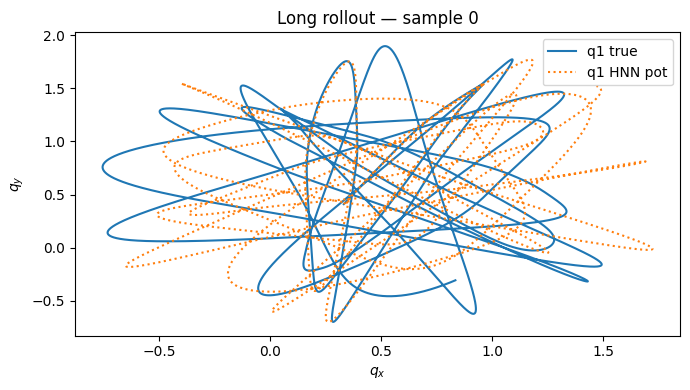

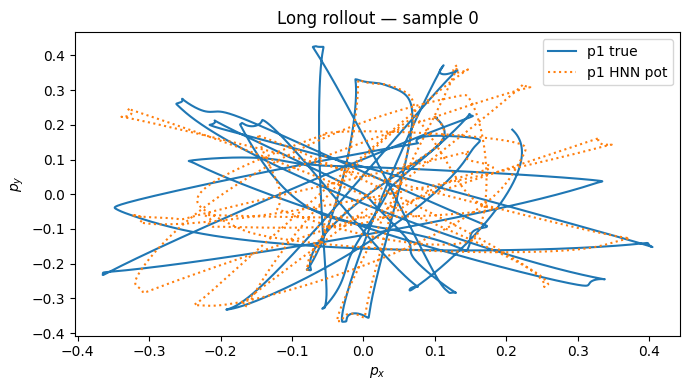

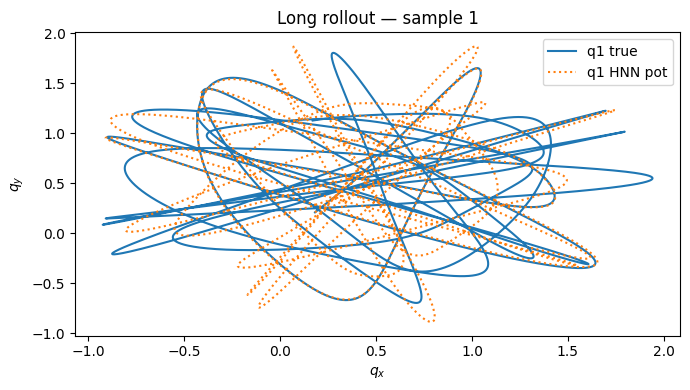

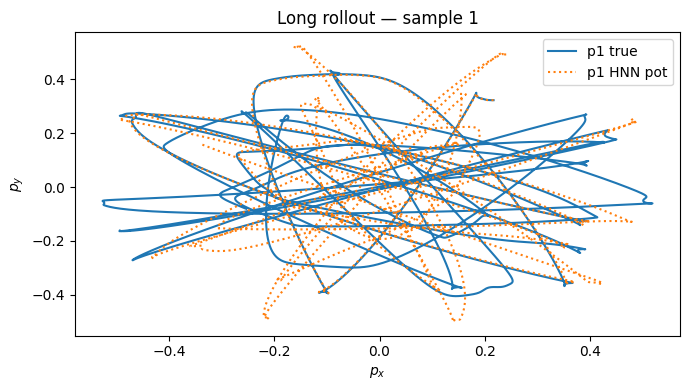

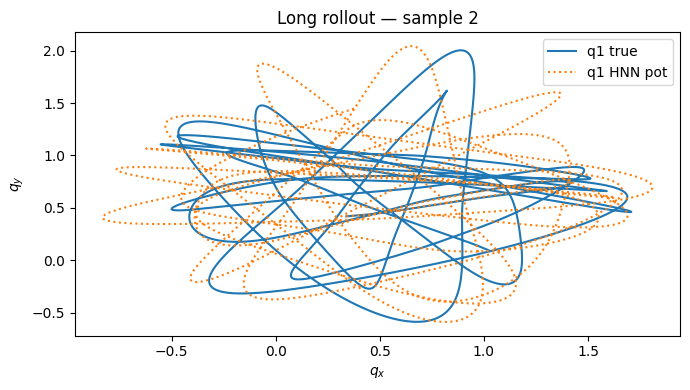

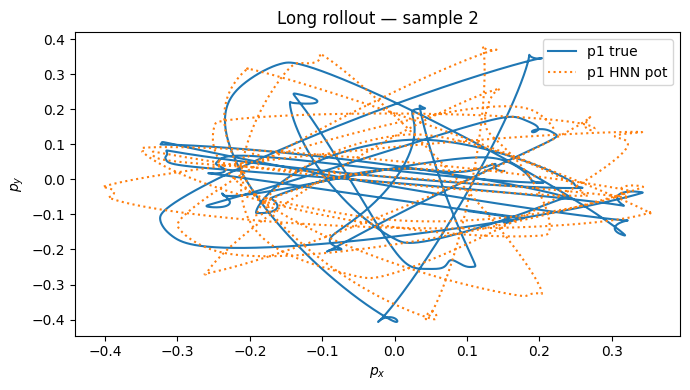

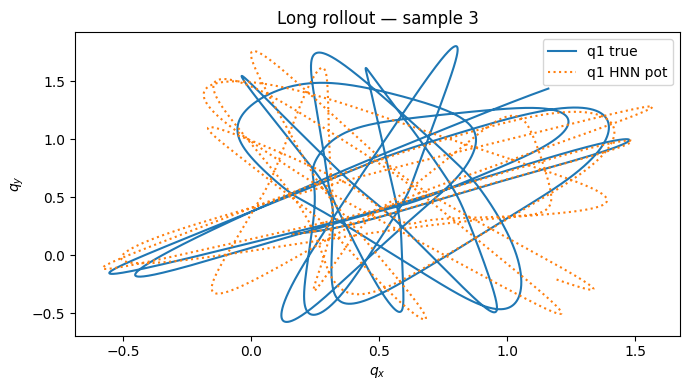

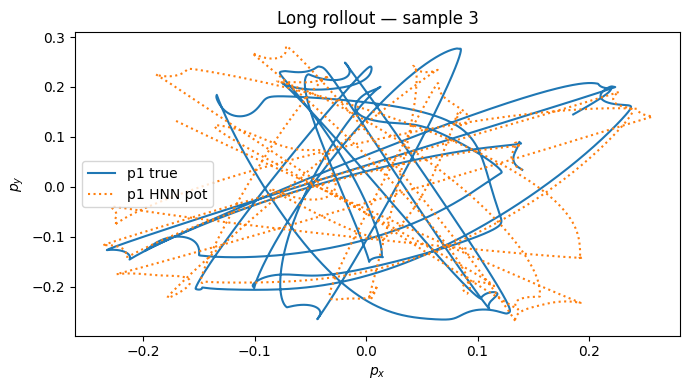

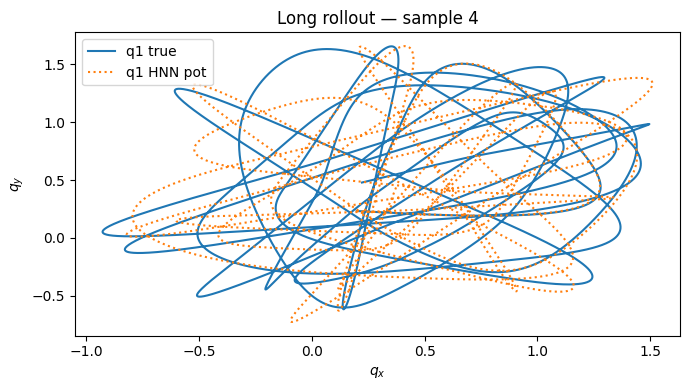

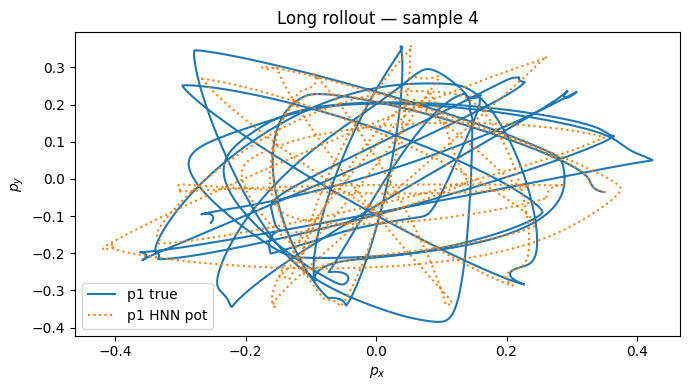

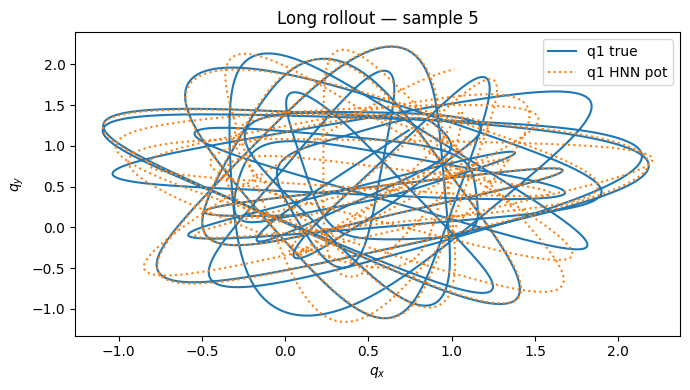

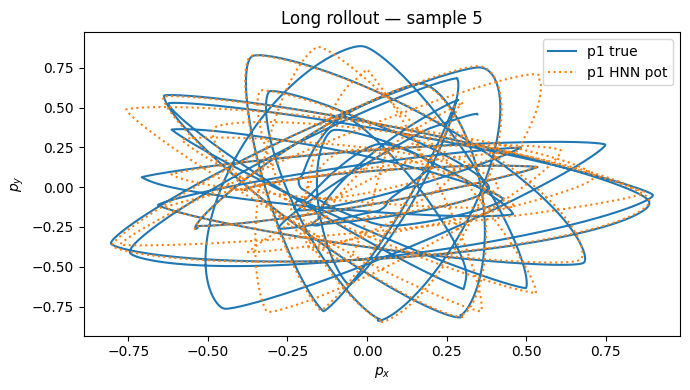

In [16]:
# ----- make a long grid (same dt) -----
def make_long_ts(ts, factor=10):
    ts = jnp.asarray(ts)
    t0 = float(ts[0]); dt = float(ts[1]-ts[0]); T = float(ts[-1]-ts[0])
    t1 = t0 + factor*T
    n = int(round((t1 - t0)/dt)) + 1
    return jnp.linspace(t0, t1, n)

ts_long = make_long_ts(ts, factor=20)   # e.g., 20x longer


# HNN long integrator
def make_hnn_long(ts_long):
    ts_host = jnp.asarray(ts_long)
    t0 = float(ts_host[0]); t1 = float(ts_host[-1])
    term = dfx.ODETerm(vector_field_hnn_potenergy)
    solver = dfx.Tsit5()
    saveat = dfx.SaveAt(ts=ts_host)
    ctrl = dfx.PIDController(rtol=1e-6, atol=1e-8)
    def run(model, params, y0s_full):
        def solve_one(y0):
            sol = dfx.diffeqsolve(term, solver, t0=t0, t1=t1, dt0=None,
                                  y0=y0, args=(model, params),
                                  saveat=saveat, stepsize_controller=ctrl)
            return sol.ys
        return jax.vmap(solve_one)(y0s_full)
    return run

def make_hnn_long_2(ts_long):
    ts_host = jnp.asarray(ts_long)
    t0 = float(ts_host[0]); t1 = float(ts_host[-1])
    term = dfx.ODETerm(vector_field_hnn_totenergy)
    solver = dfx.Tsit5()
    saveat = dfx.SaveAt(ts=ts_host)
    ctrl = dfx.PIDController(rtol=1e-6, atol=1e-8)
    def run(model, masses, y0s_full):
        def solve_one(y0):
            sol = dfx.diffeqsolve(term, solver, t0=t0, t1=t1, dt0=None,
                                  y0=y0, args=(model, masses),
                                  saveat=saveat, stepsize_controller=ctrl)
            return sol.ys
        return jax.vmap(solve_one)(y0s_full)
    return run

# # NODE long integrator
def make_node_long(ts_long):
    ts_host = jnp.asarray(ts_long)
    t0 = float(ts_host[0]); t1 = float(ts_host[-1])
    term = dfx.ODETerm(vector_field_node)
    solver = dfx.Tsit5()
    saveat = dfx.SaveAt(ts=ts_host)
    ctrl = dfx.PIDController(rtol=1e-6, atol=1e-8)
    def run(model, params, y0s_full):
        def solve_one(y0):
            sol = dfx.diffeqsolve(term, solver, t0=t0, t1=t1, dt0=None,
                                  y0=y0, args=(model, params),
                                  saveat=saveat, stepsize_controller=ctrl)
            return sol.ys
        return jax.vmap(solve_one)(y0s_full)
    return run

def make_truth_long(ts_long, params):
    ts_host = jnp.asarray(ts_long)
    t0 = float(ts_host[0]); t1 = float(ts_host[-1])
    term = dfx.ODETerm(vector_field_triangular_nonlinear_mass_spring_2d)
    solver = dfx.Tsit5()
    saveat = dfx.SaveAt(ts=ts_host)
    ctrl = dfx.PIDController(rtol=1e-6, atol=1e-8)
    def run(y0s_full):
        # def to_vel_state(y0_can):
        #     qx0,qy0,qx1,qy1,qx2,qy2,px0,py0,px1,py1,px2,py2 = y0_can
        #     return jnp.array([qx0, qy0, qx1, qy1, qx2, qy2, px0/params.m0, py0/params.m0, px1/params.m1, py1/params.m1, px2/params.m2, py2/params.m2], dtype=jnp.float32)
        def solve_one(y0_can):
            # sol = dfx.diffeqsolve(term, solver, t0=t0, t1=t1, dt0=None,
            #                       y0=to_vel_state(y0_can), args=(None, params),
            #                       saveat=saveat, stepsize_controller=ctrl)
            sol = dfx.diffeqsolve(term, solver, t0=t0, t1=t1, dt0=None,
                                  y0=y0_can, args=(None, params),
                                  saveat=saveat, stepsize_controller=ctrl)
            ys = sol.ys
            # x0,y0,x1,y1,x2,y2,vx0,vy0,vx1,vy1,vx2,vy2 = ys.T
            # px0, py0, px1, py1, px2, py2 = params.m0 * vx0, params.m0 * vy0, params.m1 * vx1, params.m1 * vy1, params.m2 * vx2, params.m2 * vy2
            # return jnp.stack([x0, y0, x1, y1, x2, y2, px0, py0, px1, py1, px2, py2], axis=-1)
            return ys
        return jax.vmap(solve_one)(y0s_full)
    return run

run_hnn_long   = make_hnn_long(ts_long)
run_hnn_long_2 = make_hnn_long_2(ts_long)
run_node_long  = make_node_long(ts_long)
run_true_long  = make_truth_long(ts_long, system_params)

B_show = 6
y0_full = val_all[:B_show, 0]                # (B,4)

hnn_model_final   = eqx.combine(hnn_potenergy_params, hnn_potenergy_static) #hnn_model_pot
hnn_model_final_2 = eqx.combine(hnn_totenergy_params, hnn_totenergy_static) #hnn_model_tot
node_model_final  = eqx.combine(node_params, node_static) #node_model

pred_hnn_long   = run_hnn_long(hnn_model_final, system_params, y0s_full=y0_full)   
pred_hnn_long_2 = run_hnn_long_2(hnn_model_final_2, system_params, y0s_full=y0_full)   
pred_node_long  = run_node_long(node_model_final, system_params, y0s_full=y0_full)
true_long       = run_true_long(y0_full)  

for i in range(B_show):
    plt.figure(figsize=(7,4))
    plt.plot(true_long[i,:,2], true_long[i,:,3],  label="q1 true")
    plt.plot(pred_hnn_long[i,:,2], pred_hnn_long[i,:,3],  ":", label="q1 HNN pot")
    #plt.plot(pred_hnn_long_2[i,:,2], pred_hnn_long_2[i,:,3], "--", label="q1 HNN tot")
    #plt.plot(pred_node_long[i,:,2], pred_node_long[i,:,3],  "-.", label="q1 NODE")
    plt.xlabel("$q_x$"); plt.ylabel("$q_y$"); plt.title(f"Long rollout — sample {i}")
    plt.legend(); plt.tight_layout()
    #plt.savefig(f"results/triple_mass_spring_q1_sample_{i}.png") 
    plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(true_long[i,:,8], true_long[i,:,9],  label="p1 true")
    plt.plot(pred_hnn_long[i,:,8], pred_hnn_long[i,:,9],  ":", label="p1 HNN pot")
    #plt.plot(pred_hnn_long_2[i,:,8], pred_hnn_long_2[i,:,9], "--", label="p1 HNN tot")
    #plt.plot(pred_node_long[i,:,8], pred_node_long[i,:,9],  "-.", label="p1 NODE")
    plt.xlabel("$p_x$"); plt.ylabel("$p_y$"); plt.title(f"Long rollout — sample {i}")
    plt.legend(); plt.tight_layout()
    #plt.savefig(f"results/triple_mass_spring_p1_sample_{i}.png")
    plt.show()

    

In [ ]:
# save_model("hnn_totenergy_triple_mass_spring", "checkpoints", hnn_model_final_2, aux={"system_params": system_params})
# save_model("hnn_potenergy_triple_mass_spring", "checkpoints", hnn_model_final, aux={"system_params": system_params})
# save_model("node_triple_mass_spring", "checkpoints", node_model_final, aux={"system_params": system_params})

In [ ]:
true_long.shape

(6, 20001, 12)

In [ ]:
from vector_fields import _pair_extention_direction

def total_energy(y, params: Params):
    qx0,qy0,qx1,qy1,qx2,qy2,px0,py0,px1,py1,px2,py2 = y[...,0], y[...,1], y[...,2], y[...,3], y[...,4], y[...,5], y[...,6], y[...,7], y[...,8], y[...,9], y[...,10], y[...,11]
    
    r0 = jnp.array([qx0,qy0]);   r1 = jnp.array([qx1,qy1]);   r2 = jnp.array([qx2,qy2])

    e01, _ = _pair_extention_direction(r0, r1, params.L01)
    e02, _ = _pair_extention_direction(r0, r2, params.L02)
    e12, _ = _pair_extention_direction(r1, r2, params.L12)

    KE = 0.5*((px0**2 + py0**2)/params.m0 + (px1**2 + py1**2)/params.m1 + (px2**2 + py2**2)/params.m2)
    PE = 0.5*(params.k0*e01**2 + params.k1*e12**2 + params.k2*e02**2)
    return KE, PE

def hnn_predicted_energy_2(model, y):
    H = lambda y_: model(y_)                     # scalar, total energy
    return jax.vmap(H)(y)

def hnn_predicted_energy(model, y, params: Params):
    KE, _ = total_energy(y, params)
    PE = lambda y: model(y[:3])                     # scalar, total energy
    return KE + jax.vmap(PE)(y)

for i in range(B_show):
    KE_true, PE_true = total_energy(true_long[i], system_params)
    E_true = KE_true + PE_true
    #E_hnn = hnn_predicted_energy(hnn_model_final, true_long[i], system_params) - hnn_model_final(jnp.array([system_params.L0, system_params.L0+system_params.L1, system_params.L0+system_params.L1+system_params.L2]))  # shift to zero baseline
    E_hnn_2 = hnn_predicted_energy_2(hnn_model_final_2, true_long[i]) #- hnn_model_final_2(jnp.array([system_params.L0, system_params.L0+system_params.L1, system_params.L0+system_params.L1+system_params.L2, 0., 0., 0.]))  # shift to zero baseline

    plt.figure(figsize=(7,4))
    plt.plot(ts_long, E_true, label="True")
    #plt.plot(ts_long, E_hnn, "--", label="HNN")
    plt.plot(ts_long, E_hnn_2, label="HNN 2")
    plt.xlabel("t"); plt.ylabel("Total Energy"); plt.title(f"Total Energy — sample {i}")
    plt.legend(); plt.tight_layout(); plt.show()

TypeError: dot_general requires contracting dimensions to have the same shape, got (20001,) and (2,).

In [ ]:
true_long.shape

(6, 20001, 12)

In [17]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib import animation
from pathlib import Path

def animate_mass_spring_2d_jax(
    y,                         # jnp.ndarray or np.ndarray with shape [N, 4*M]
    edges=None,                # list of (i,j) springs; default triangle (M=3) else chain
    save_path="mass_springs.gif",
    fps=30,
    dpi=120,
    show_momenta=False,
    momentum_scale=0.2,
    mass_markersize=8,
    trail_len=None,            # e.g. 50 to show recent trajectory; None for no trails
    title=None,
    tight_limits=True,
    margin=0.1,                # padding fraction for axes
    frame_step=4,              # subsample frames (e.g., 2 draws every other frame)
):
    """
    Animate a 2D mass–spring system from state history.

    State layout per frame: [qx0,qy0, qx1,qy1, ..., px0,py0, px1,py1, ...].

    Parameters
    ----------
    y : [N, 4*M]
        JAX or NumPy array of system states over time.
    edges : list[(int,int)] or None
        Which masses are connected by springs. Defaults:
          - M==3: triangle [(0,1),(1,2),(2,0)]
          - else: chain [(0,1),(1,2),...,(M-2,M-1)]
    save_path : str
        Output file with .gif or .mp4 extension.
    fps : int
        Frames per second.
    dpi : int
        Figure DPI.
    show_momenta : bool
        Draw arrows for momenta p (scaled by momentum_scale).
    momentum_scale : float
        Visual scale for momentum arrows (unit-dependent).
    mass_markersize : float
        Marker size for masses.
    trail_len : int or None
        If set, draw last `trail_len` positions per mass as a trail.
    title : str or None
        Figure title.
    tight_limits : bool
        Compute global axes from all positions to avoid jitter.
    margin : float
        Fractional padding for the axes around min/max.
    frame_step : int
        Use every k-th frame for speed.
    """
    # Bring data to host NumPy (Matplotlib needs NumPy arrays)
    y_np = np.asarray(jax.device_get(y))
    assert y_np.ndim == 2, "y must be [N, 4*M]"
    N, D = y_np.shape
    assert D % 4 == 0, "State dimension must be divisible by 4 (qx,qy,...,px,py,...)"
    M = D // 4

    # Subsample frames if requested
    idx = np.arange(0, N, frame_step, dtype=int)
    y_np = y_np[idx]
    N = y_np.shape[0]

    # Unpack
    pos = y_np[:, : 2 * M].reshape(N, M, 2)        # [N, M, 2] -> (x,y)
    mom = y_np[:, 2 * M : 4 * M].reshape(N, M, 2)  # [N, M, 2]

    # Default spring topology
    if edges is None:
        edges = [(0, 1), (1, 2), (2, 0)] if M == 3 else [(i, i + 1) for i in range(M - 1)]

    # Axis limits
    if tight_limits:
        xmin = pos[:, :, 0].min()
        xmax = pos[:, :, 0].max()
        ymin = pos[:, :, 1].min()
        ymax = pos[:, :, 1].max()
        dx = xmax - xmin
        dy = ymax - ymin
        pad_x = margin * (dx if dx > 0 else 1.0)
        pad_y = margin * (dy if dy > 0 else 1.0)
        xmin, xmax = xmin - pad_x, xmax + pad_x
        ymin, ymax = ymin - pad_y, ymax + pad_y

    # Figure
    fig, ax = plt.subplots(figsize=(6, 6), dpi=dpi)
    if title:
        ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    if tight_limits:
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)

    # --- create artists ---
    mass_scatter, = ax.plot([], [], "o", ms=mass_markersize)
    spring_lines = [ax.plot([], [], "-")[0] for _ in edges]
    time_text = ax.text(0.02, 0.98, "", transform=ax.transAxes, va="top")

    # Optional trails
    trail_lines = None
    if trail_len and trail_len > 0:
        trail_lines = [ax.plot([], [], "-", alpha=0.6)[0] for _ in range(M)]

    # Momentum arrows (initialized with zero-length vectors)
    mom_quiver = None
    if show_momenta:
        mom_quiver = ax.quiver(
            pos[0, :, 0], pos[0, :, 1],
            np.zeros(M), np.zeros(M),
            angles="xy", scale_units="xy", scale=1.0
        )

    # --- init function ---
    def init():
        mass_scatter.set_data([], [])
        for ln in spring_lines:
            ln.set_data([], [])
        if trail_lines:
            for ln in trail_lines:
                ln.set_data([], [])
        time_text.set_text("")
        # Do NOT reset quiver to empty — leave it initialized
        return [
            mass_scatter, *spring_lines,
            *(trail_lines or []),
            *( [mom_quiver] if mom_quiver else [] ),
            time_text,
        ]

    # --- update function ---
    def update(frame):
        xs = pos[frame, :, 0]
        ys = pos[frame, :, 1]
        mass_scatter.set_data(xs, ys)

        # springs
        for ln, (i, j) in zip(spring_lines, edges):
            ln.set_data([pos[frame, i, 0], pos[frame, j, 0]],
                        [pos[frame, i, 1], pos[frame, j, 1]])

        # trails
        if trail_lines:
            start = max(0, frame - trail_len + 1)
            for m, ln in enumerate(trail_lines):
                ln.set_data(pos[start:frame + 1, m, 0],
                            pos[start:frame + 1, m, 1])

        # momenta
        if mom_quiver:
            mom_quiver.set_offsets(pos[frame])
            mom_quiver.set_UVC(
                mom[frame, :, 0] * momentum_scale,
                mom[frame, :, 1] * momentum_scale,
            )

        time_text.set_text(f"frame {frame+1}/{N}")
        return [
            mass_scatter, *spring_lines,
            *(trail_lines or []),
            *( [mom_quiver] if mom_quiver else [] ),
            time_text,
        ]

    anim = animation.FuncAnimation(
        fig, update, init_func=init, frames=N, interval=1000 / fps, blit=True
    )

    # Save
    save_path = str(Path(save_path))
    ext = Path(save_path).suffix.lower()
    if ext == ".gif":
        try:
            writer = animation.PillowWriter(fps=fps)
        except Exception as e:
            plt.close(fig)
            raise RuntimeError("Saving GIF requires Pillow. Install with `pip install pillow`.") from e
        anim.save(save_path, writer=writer, dpi=dpi)
    elif ext == ".mp4":
        try:
            writer = animation.FFMpegWriter(fps=fps)
        except Exception as e:
            plt.close(fig)
            raise RuntimeError("Saving MP4 requires ffmpeg available on PATH.") from e
        anim.save(save_path, writer=writer, dpi=dpi)
    else:
        plt.close(fig)
        raise ValueError("save_path must end with .gif or .mp4")

    plt.close(fig)
    return save_path, anim 

In [ ]:
path, _ = animate_mass_spring_2d_jax(
    y=true_long[1],
    edges=[(0,1), (1,2), (2,0)],   # omit to auto-triangle for M=3
    save_path="checkpoints/spring_constant_0-1/true_long.gif",
    fps=30,
    show_momenta=True,
    momentum_scale=0.15,
    trail_len=40,
    title="3-mass spring system",
    frame_step=8
)
print("Saved to:", path)

Saved to: checkpoints/spring_constant_0-05/true_long.gif


In [18]:
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'Palatino'
plt.rcParams['font.style'] = 'normal'

sintef_blue = '#003C65'
sintef_cyan = '#22A7E5'
sintef_green = '#A4C21F'
sintef_yellow = '#F7E918'
sintef_magenta = '#EC008C'

### Updated plotting function for comparing trajectories

In [19]:
def animate_mass_spring_2d_grid_jax(
    y_true,                      # [N, 4*M] true trajectory
    y_pred1=None,                # [N, 4*M] or None
    y_pred2=None,
    y_pred3=None,
    y_pred4=None,
    edges=None,                  # list of (i,j) springs; default triangle/chain
    labels=None,                 # list of labels for each prediction panel
    save_path="mass_springs_2d_grid.mp4",
    fps=30,
    dpi=120,
    mass_markersize=8,
    trail_len=None,              # e.g. 50; None for no trails
    title=None,
    tight_limits=True,
    margin=0.1,                  # padding fraction for axes
    frame_step=8,                # subsample frames
):
    """
    Animate a 2D mass–spring system, comparing multiple predicted trajectories
    against a common true trajectory, in a grid of 2D subplots.

    State layout per frame: [qx0,qy0, ..., px0,py0, ...]
    → shape [N, 4*M].

    Parameters
    ----------
    y_true : [N, 4*M]
        JAX or NumPy array of true system states over time.
    y_pred1..4 : [N, 4*M] or None
        Predicted trajectories to compare (each panel: true vs one prediction).
    edges : list[(int,int)] or None
        Spring topology. Defaults:
          - M==3: triangle [(0,1),(1,2),(2,0)]
          - else: chain [(0,1),(1,2),...,(M-2,M-1)]
    labels : list[str] or None
        Labels for panels (e.g., ["HNN", "NODE", "Baseline"]). If None, auto.
    save_path : str
        Output file (.gif or .mp4).
    """

    # Collect predictions into a list
    preds_raw = [y_pred1, y_pred2, y_pred3, y_pred4]
    preds_raw = [p for p in preds_raw if p is not None]
    K = len(preds_raw)
    if K == 0:
        raise ValueError("At least one prediction (y_pred1..y_pred4) must be provided.")
    if K > 4:
        raise ValueError("At most 4 predictions supported.")

    # Bring true data to host NumPy
    y_true_np = np.asarray(jax.device_get(y_true))
    assert y_true_np.ndim == 2, "y_true must be [N, 4*M]"
    N, D = y_true_np.shape
    assert D % 4 == 0, "State dim must be divisible by 4 (qx,qy,...,px,py,...)"
    M = D // 4

    # Bring preds to NumPy and validate shapes
    preds_np = []
    for p in preds_raw:
        p_np = np.asarray(jax.device_get(p))
        assert p_np.shape == y_true_np.shape, "All predictions must have same shape as y_true"
        preds_np.append(p_np)

    # Subsample frames
    idx = np.arange(0, N, frame_step, dtype=int)
    y_true_np = y_true_np[idx]
    preds_np = [p[idx] for p in preds_np]
    N = y_true_np.shape[0]

    # Unpack true trajectory positions: [N, 2*M] -> [N, M, 2]
    pos_true = y_true_np[:, : 2 * M].reshape(N, M, 2)

    # Unpack predictions
    pos_preds = [p[:, : 2 * M].reshape(N, M, 2) for p in preds_np]

    # Default edges
    if edges is None:
        edges = [(0, 1), (1, 2), (2, 0)] if M == 3 else [(i, i + 1) for i in range(M - 1)]

    # Axis limits over true + all preds
    if tight_limits:
        all_pos = [pos_true] + pos_preds
        all_pos_concat = np.concatenate(all_pos, axis=0)  # [N_total, M, 2]

        xmin = all_pos_concat[:, :, 0].min()
        xmax = all_pos_concat[:, :, 0].max()
        ymin = all_pos_concat[:, :, 1].min()
        ymax = all_pos_concat[:, :, 1].max()

        dx = xmax - xmin
        dy = ymax - ymin

        pad_x = margin * (dx if dx > 0 else 1.0)
        pad_y = margin * (dy if dy > 0 else 1.0)

        xmin, xmax = xmin - pad_x, xmax + pad_x
        ymin, ymax = ymin - pad_y, ymax + pad_y

    # Panel labels
    if labels is None:
        labels = [f"Model {i+1}" for i in range(K)]
    else:
        assert len(labels) == K, "labels must have same length as number of predictions"

    # Layout: same spirit as your current code
    if K <= 2:
        nrows, ncols = 1, K
    elif K == 3:
        nrows, ncols = 1, 3
    else:  # K == 4
        nrows, ncols = 1, 4

    # Colors per mass
    mass_colors = ['#1f77b4', '#ff7f0e', '#1f77b4']  # blue, orange, blue
    if M > 3:
        mass_colors = (mass_colors * ((M + 2) // 3))[:M]

    # --- Figure + axes (tight layout using GridSpec) ---
    fig = plt.figure(figsize=(5 * ncols, 5 * nrows), dpi=dpi)
    gs = fig.add_gridspec(nrows, ncols, wspace=0.02, hspace=0.02)

    axes = []
    panel_indices = []
    pred_idx = 0

    for r in range(nrows):
        for c in range(ncols):
            ax_idx = r * ncols + c
            ax = fig.add_subplot(gs[r, c])

            if ax_idx < K:
                axes.append(ax)
                panel_indices.append(pred_idx)
                pred_idx += 1
            else:
                ax.set_axis_off()
                axes.append(ax)
                panel_indices.append(None)

    fig.tight_layout(pad=0.2, w_pad=0.05, h_pad=0.05)
    if title:
        fig.suptitle(title)

    # Set common limits and labels
    for ax, pidx in zip(axes, panel_indices):
        if pidx is None:
            continue
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        if tight_limits:
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)
        ax.set_title(labels[pidx])
        ax.set_aspect("equal", adjustable="box")

    # --- Create artists for each active panel ---
    panels = []

    for ax, pidx in zip(axes, panel_indices):
        if pidx is None:
            panels.append(None)
            continue

        mass_markers_true = []
        mass_markers_pred = []

        for i in range(M):
            # true masses: squares
            sc_true, = ax.plot(
                [], [], "s",
                ms=mass_markersize * 0.8,
                color=mass_colors[i],
                alpha=0.6,
                zorder=4,
                label="true" if i == 0 else None,
            )
            mass_markers_true.append(sc_true)

            # predicted masses: circles
            sc_pred, = ax.plot(
                [], [], "o",
                ms=mass_markersize,
                color=mass_colors[i],
                zorder=5,
                label="pred" if i == 0 else None,
            )
            mass_markers_pred.append(sc_pred)

        spring_true = [
            ax.plot([], [], "--", color="gray", lw=1.0, alpha=0.6, zorder=0)[0]
            for _ in edges
        ]
        spring_pred = [
            ax.plot([], [], "-", color="gray", lw=1.5, zorder=1)[0]
            for _ in edges
        ]

        trail_true = None
        trail_pred = None
        if trail_len and trail_len > 0:
            trail_true = [
                ax.plot([], [], "--", alpha=0.5, color=mass_colors[m], lw=1)[0]
                for m in range(M)
            ]
            trail_pred = [
                ax.plot([], [], "-", alpha=0.7, color=mass_colors[m], lw=1)[0]
                for m in range(M)
            ]

        panels.append(
            dict(
                ax=ax,
                pidx=pidx,
                mass_true=mass_markers_true,
                mass_pred=mass_markers_pred,
                spring_true=spring_true,
                spring_pred=spring_pred,
                trail_true=trail_true,
                trail_pred=trail_pred,
            )
        )

    # One time text for the whole figure
    time_text = fig.text(0.01, 0.01, "", va="bottom", ha="left")

    # --- init function ---
    def init():
        for panel in panels:
            if panel is None:
                continue
            for sc in panel["mass_true"]:
                sc.set_data([], [])
            for sc in panel["mass_pred"]:
                sc.set_data([], [])
            for ln in panel["spring_true"]:
                ln.set_data([], [])
            for ln in panel["spring_pred"]:
                ln.set_data([], [])
            if panel["trail_true"]:
                for ln in panel["trail_true"]:
                    ln.set_data([], [])
            if panel["trail_pred"]:
                for ln in panel["trail_pred"]:
                    ln.set_data([], [])
        time_text.set_text("")
        return [time_text]

    # --- update function ---
    def update(frame):
        pt = pos_true[frame]  # [M, 2]

        for panel in panels:
            if panel is None:
                continue

            pidx = panel["pidx"]
            pp = pos_preds[pidx][frame]  # [M, 2]

            # masses
            for i, sc in enumerate(panel["mass_true"]):
                sc.set_data([pt[i, 0]], [pt[i, 1]])
            for i, sc in enumerate(panel["mass_pred"]):
                sc.set_data([pp[i, 0]], [pp[i, 1]])

            # springs
            for ln, (i, j) in zip(panel["spring_true"], edges):
                ln.set_data([pt[i, 0], pt[j, 0]], [pt[i, 1], pt[j, 1]])
            for ln, (i, j) in zip(panel["spring_pred"], edges):
                ln.set_data([pp[i, 0], pp[j, 0]], [pp[i, 1], pp[j, 1]])

            # trails
            if panel["trail_true"] or panel["trail_pred"]:
                start = max(0, frame - (trail_len or 0) + 1)

            if panel["trail_true"]:
                for m, ln in enumerate(panel["trail_true"]):
                    ln.set_data(
                        pos_true[start:frame + 1, m, 0],
                        pos_true[start:frame + 1, m, 1],
                    )

            if panel["trail_pred"]:
                pos_p_all = pos_preds[pidx]
                for m, ln in enumerate(panel["trail_pred"]):
                    ln.set_data(
                        pos_p_all[start:frame + 1, m, 0],
                        pos_p_all[start:frame + 1, m, 1],
                    )

        time_text.set_text(f"frame {frame+1}/{N}")
        return [time_text]

    anim = animation.FuncAnimation(
        fig, update, init_func=init, frames=N, interval=1000 / fps, blit=False
    )

    # Save
    save_path = str(Path(save_path))
    ext = Path(save_path).suffix.lower()
    if ext == ".gif":
        try:
            writer = animation.PillowWriter(fps=fps)
        except Exception as e:
            plt.close(fig)
            raise RuntimeError("Saving GIF requires Pillow.") from e
        anim.save(save_path, writer=writer, dpi=dpi)
    elif ext == ".mp4":
        try:
            writer = animation.FFMpegWriter(fps=fps)
        except Exception as e:
            plt.close(fig)
            raise RuntimeError("Saving MP4 requires ffmpeg on PATH.") from e
        anim.save(save_path, writer=writer, dpi=dpi)
    else:
        plt.close(fig)
        raise ValueError("save_path must end with .gif or .mp4")

    plt.close(fig)
    return save_path, anim


In [20]:
path, anim = animate_mass_spring_2d_grid_jax(
    y_true=true_long[2],
    y_pred1=pred_node_long[2],
    y_pred2=pred_hnn_long[2],
    y_pred3=pred_hnn_long_2[2],
    y_pred4=None,  # optional
    edges=[(0,1),(1,2),(2,0)],
    labels=["NODE", "HNN (tot, rel)", "HNN (pot, rel)"],
    save_path="compare_3_models_2d_grid3_v2_500ep.mp4",
    trail_len=40,
    frame_step=10,
    title="",
)
print("Saved to:", path)

/var/folders/63/lsr6bh597y9gd6cc0mp34_jh0000gn/T/ipykernel_22785/3927617900.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.2, w_pad=0.05, h_pad=0.05)


Saved to: compare_3_models_2d_grid3_v2_500ep.mp4
